# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean()*100)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean()*100)

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- **¿Qué columnas tienen valores faltantes y en qué proporción?**
- En el dataset users se identificaron valores faltantes en las variables city y churn_date.
- En el dataset usage se identificaron valores faltantes en las variables date, duration y length.
- **Indica qué harías: ¿imputar, eliminar, ignorar?**
- La variable **churn_date** presenta **3.534** valores nulos, equivalentes al **88,35 %** de los registros. Considerando que esta variable corresponde a la fecha de cancelación del servicio, los valores nulos pueden interpretarse como clientes que continúan activos y, por tanto, no cuentan con una fecha de abandono registrada. En consecuencia, se decide conservar e ignorar estos valores nulos, ya que forman parte de la lógica del negocio y serán necesarios para diferenciar posteriormente entre clientes activos e inactivos.
- La variable **city** contiene **469** valores nulos, correspondientes al **11,72 %** del total de usuarios. Debido a que la ciudad puede ser relevante para la caracterización y segmentación de los clientes, se decide imputar los valores faltantes mediante una categoría como “No informado”. De esta forma se conservan los registros sin asignar una ciudad que no pueda ser determinada con la información disponible.
- La variable **date** presenta **50** valores nulos, equivalentes al **0,12 %** de los registros. Debido a que la fecha es necesaria para realizar análisis temporales del consumo y la cantidad de registros afectados es mínima, se decide eliminar los registros que no contienen fecha.
- La variable **duration** presenta **22.076** valores nulos, equivalentes al **55,19 %**, mientras que **length** presenta **17.896** valores nulos, correspondientes al **44,74 %**. Teniendo en cuenta que el dataset usage contiene diferentes tipos de consumo, como llamadas y mensajes, estos valores faltantes pueden corresponder a variables que no aplican para determinados tipos de registro: duration para las llamadas y length para los mensajes. Por lo tanto, se decide conservar e ignorar estos valores nulos, evitando imputarlos con cero u otro valor que pueda alterar el significado real de los datos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users[['user_id','age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`presenta valores entre 10.000 y 13.999. Aunque su tipo de dato es numérico, corresponde a un identificador de usuario, por lo que medidas como promedio, desviación estándar o percentiles no tienen una interpretación analítica relevante. No se observan valores atípicos evidentes a partir del rango presentado; adicionalmente, conviene validar que cada identificador sea único.
- La columna `age` presenta edades entre -999 y 79 años. El valor mínimo de -999 no corresponde a una edad válida y se identifica como un valor sentinel, probablemente utilizado para representar información faltante o desconocida. Este valor altera significativamente estadísticas como la media y la desviación estándar.

In [13]:
# explorar columnas numéricas de usage
usage[['id','user_id']].describe()

,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


- La columna id presenta valores entre 1 y 40.000. Aunque está almacenada como variable numérica, corresponde al identificador único de cada registro de uso, por lo que medidas estadísticas como la media, desviación estándar y percentiles no tienen una interpretación analítica relevante. El rango observado no evidencia valores inválidos; sin embargo, se debe validar que no existan identificadores duplicados.
- La columna user_id presenta valores entre 10.000 y 13.999, rango consistente con los identificadores observados en el dataset users. Al tratarse de una clave que relaciona cada registro de consumo con un cliente, sus estadísticas descriptivas tampoco tienen una interpretación cuantitativa. No se identifican valores inválidos a partir del rango observado, aunque posteriormente debe verificarse que todos los user_id registrados en usage tengan correspondencia en el dataset users.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].value_counts()

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

- La columna `city` contiene ciudades de Colombia y México como Bogotá, Medellín, Cali, CDMX, GDL y MTY. Sin embargo, también se identifica el valor ?, el cual no corresponde a una ciudad válida y se considera un valor sentinel utilizado para representar información desconocida o no registrada.
- La columna `plan` presenta únicamente las categorías Basico y Premium, sin evidenciar categorías inválidas o sentinels. Estas categorías son consistentes con los planes ofrecidos por la compañía, por lo que no requieren tratamiento adicional.

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` presenta únicamente los valores text y call, correspondientes a mensajes y llamadas respectivamente. No se identifican categorías inválidas ni valores sentinel, por lo que no requiere tratamiento adicional. Además, esta clasificación permite sustentar que los valores nulos presentes en duration y length pueden estar asociados al tipo de servicio registrado y corresponder a valores que no aplican para determinadas observaciones.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- age y city de users 
- ¿Qué acción tomarías?
- en age, cuantificar cuántos registros contienen -999 y posteriormente reemplazar este valor por NaN para aplicar imputacion por media o mediana de acuerdo a su desviacion.
- en city, reemplazar el valor "?" por NaN y posteriormente aplicar el mismo tratamiento definido para los valores faltantes de esta variable, imputándolos con la categoría "No informado".

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        3531 non-null   object        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 250.1+ KB


In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  float64       
 5   length    22104 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 1.8+ MB


In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se identifica que contiene registros correspondientes a los años 2022, 2023, 2024 y 2026. Dado que el alcance del dataset comprende información únicamente hasta el año 2024, los 40 registros correspondientes a 2026 (1 % del total) se consideran valores inválidos, ya que representan fechas posteriores al periodo de observación definido para el proyecto.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, 39.950 registros correspondientes al año 2024, lo cual es consistente con el periodo de análisis definido para el proyecto. No se identifican años futuros ni fechas fuera del rango esperado.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- Si, reg_date registra datos del año 2026
- ¿Qué harías con ellas?
- Se recomeinda reemplazar las fechas posteriores a 2024 por valores nulos (NaT) y conservar los registros de los usuarios, evitando eliminar información que podría estar relacionada con el dataset usage.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
users['age'] = users['age'].replace(-999, np.nan)
age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts()


Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)


type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`:

Los valores nulos identificados en duration para los registros de tipo text son coherentes con la naturaleza de la variable, ya que un mensaje de texto no tiene una duración asociada. Por lo tanto, estos valores se consideran nulos estructurales y no requieren imputación.

De igual manera, los valores nulos presentes en length para los registros de tipo call son consistentes con el tipo de registro, debido a que una llamada no contiene una cantidad de caracteres asociada. En consecuencia, estos valores también se consideran nulos estructurales y se conservarán sin imputación.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = (
    usage
    .groupby("user_id")
    .agg(
        total_texts=("is_text", "sum"),
        total_calls=("is_call", "sum"),
        total_call_duration=("duration", "sum"),
    )
    .reset_index()
)

# observar resultado
usage_agg.head(3)

,user_id,total_texts,total_calls,total_call_duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'total_texts':'cant_mensajes','total_calls':'cant_llamadas','total_call_duration':'cant_minutos_llamada','total_text_length':'cant_caracteres_mensaje'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [44]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_agg,
    on='user_id',
    how='left'
)
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


In [42]:
user_profile[
    user_profile['cant_mensajes'].isna()
]

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
1082,11082,Luis,Gomez,39.0,CDMX,2022-10-24 06:31:03.465866468,Basico,NaN,NaN,NaN,NaN


In [46]:
columnas_consumo = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

user_profile[columnas_consumo] = (
    user_profile[columnas_consumo].fillna(0)
)

### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [47]:
# Resumen estadístico de las columnas numéricas
user_profile[['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.136000,5.523000,4.477000,23.311225
std,17.689919,2.359738,2.145139,18.169564
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.107500
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.412500
max,79.000000,17.000000,15.000000,155.690000


In [48]:
user_profile[['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']].median()

age                     48.00
cant_mensajes            5.00
cant_llamadas            4.00
cant_minutos_llamada    19.78
dtype: float64

In [49]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

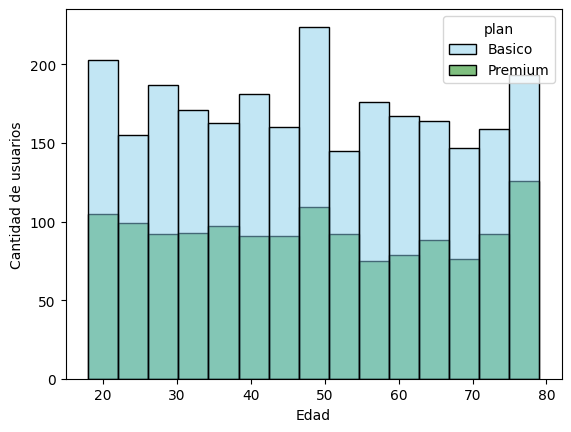

In [50]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    bins=15,
    palette=['skyblue','green']
)

plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- La distribución de edades es relativamente homogénea a lo largo del rango analizado, aunque se observan algunas concentraciones en los intervalos cercanos a los 20, 50 y 80 años. El plan Básico presenta una mayor cantidad de usuarios en prácticamente todos los rangos de edad, lo cual puede estar relacionado con que este plan cuenta con una mayor cantidad de clientes en términos generales. En el plan Premium se observa una concentración relativamente mayor en el rango de edades más altas, especialmente entre aproximadamente 75 y 80 años. Sin embargo, a partir de las frecuencias absolutas no es posible concluir que los usuarios de mayor edad tengan una mayor preferencia por el plan Premium.

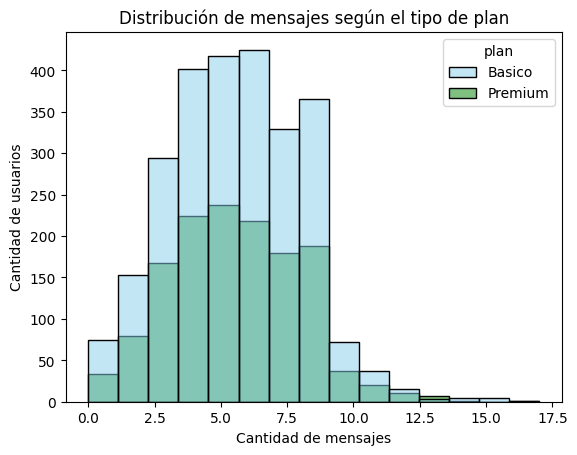

In [51]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    bins=15,
    palette=['skyblue', 'green']
)

plt.title('Distribución de mensajes según el tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- La distribución de la cantidad de mensajes presenta un sesgo hacia la derecha, debido a que la mayoría de los usuarios se concentra en niveles bajos y medios de consumo, principalmente entre aproximadamente 3 y 8 mensajes, mientras que un grupo reducido registra cantidades superiores, generando una cola hacia valores más altos.

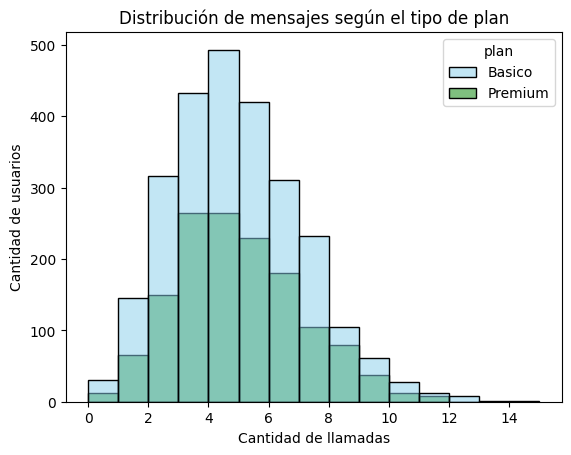

In [52]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    bins=15,
    palette=['skyblue', 'green']
)

plt.title('Distribución de mensajes según el tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- La distribución de la cantidad de llamadas presenta un sesgo hacia la derecha, debido a que la mayoría de los usuarios se concentra en niveles bajos y medios de consumo, principalmente entre aproximadamente 3 y 8 llamadas, mientras que un grupo reducido registra cantidades superiores, generando una cola hacia valores más altos.

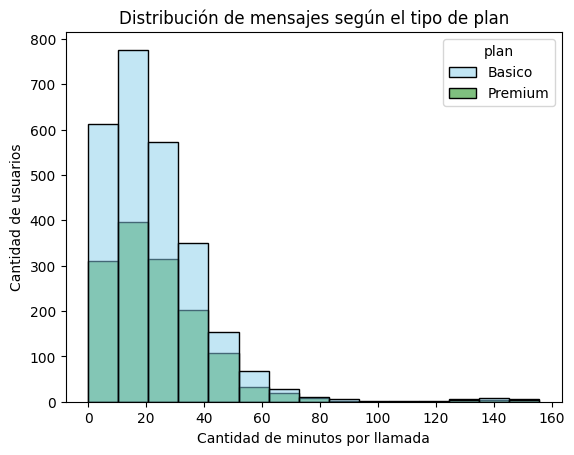

In [53]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    bins=15,
    palette=['skyblue', 'green']
)

plt.title('Distribución de mensajes según el tipo de plan')
plt.xlabel('Cantidad de minutos por llamada')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- La distribución de los minutos totales de llamada presenta un marcado sesgo hacia la derecha. La mayor parte de los usuarios concentra su consumo aproximadamente entre 0 y 40 minutos, mientras que la frecuencia disminuye progresivamente a medida que aumenta el tiempo de llamada.
Se observa además un pequeño grupo de usuarios con consumos considerablemente superiores al comportamiento general, incluyendo registros cercanos a 130–160 minutos, los cuales podrían considerarse potenciales valores atípicos y deberían evaluarse posteriormente.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

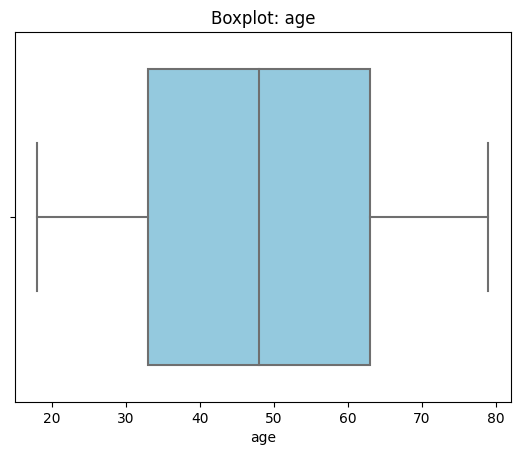

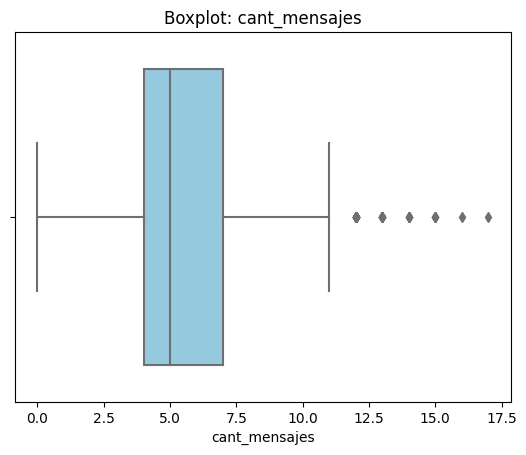

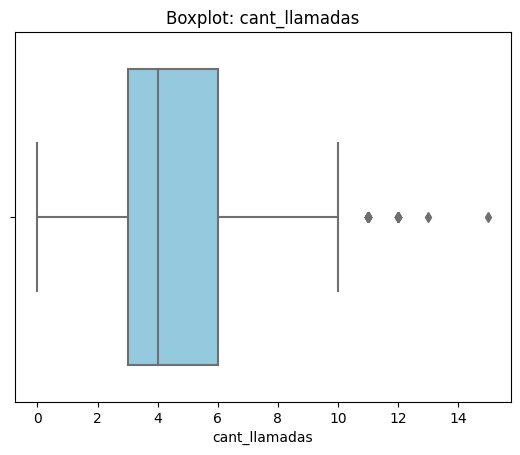

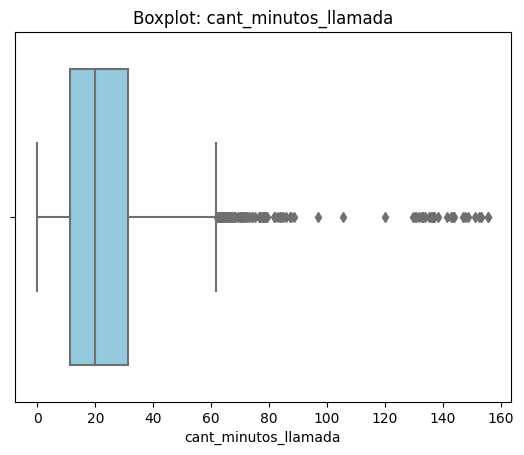

In [54]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(
        data=user_profile,
        x=col,
        color='skyblue'
    )
    
    plt.xlabel(col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No presenta valores atípicos. Las edades se encuentran dentro de un rango razonable de 18 a 79 años y no se observan puntos fuera de los bigotes del boxplot.
- cant_mensajes: Presenta outliers superiores. La mayoría de los usuarios se concentra aproximadamente entre 4 y 7 mensajes, pero se observan usuarios con cantidades significativamente mayores, principalmente a partir de aproximadamente 12 mensajes.
- cant_llamadas: Presenta outliers superiores. La mayor parte de los usuarios realiza entre aproximadamente 3 y 6 llamadas, mientras que algunos usuarios registran cantidades superiores al comportamiento habitual, principalmente por encima de aproximadamente 10–11 llamadas.
- cant_minutos_llamada: Presenta una cantidad considerable de outliers superiores. La mayor parte de los usuarios acumula un consumo relativamente bajo o moderado de minutos, mientras que existen usuarios con consumos superiores a aproximadamente 62 minutos, incluyendo algunos casos cercanos a 130–156 minutos. Esto es consistente con el sesgo hacia la derecha identificado previamente en la distribución.

In [55]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR

    print(f'\nVariable: {col}')
    print('Primer cuartil:', Q1)
    print('Tercer cuartil:', Q3)
    print('IQR:', IQR)
    print('Límite superior:', limite_superior)




Variable: cant_mensajes
Primer cuartil: 4.0
Tercer cuartil: 7.0
IQR: 3.0
Límite superior: 11.5

Variable: cant_llamadas
Primer cuartil: 3.0
Tercer cuartil: 6.0
IQR: 3.0
Límite superior: 10.5

Variable: cant_minutos_llamada
Primer cuartil: 11.1075
Tercer cuartil: 31.4125
IQR: 20.305
Límite superior: 61.870000000000005


In [56]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Mantener los outliers. Los valores superiores a 11,5 mensajes son considerados estadísticamente atípicos según el método IQR; sin embargo, el máximo observado es de 17 mensajes, un valor posible dentro del comportamiento de un cliente. No existe evidencia de que estos registros correspondan a errores, por lo que se conservan como usuarios con un nivel de consumo superior al habitual.
- cant_llamadas: Mantener los outliers. Los usuarios con 11 o más llamadas se encuentran por encima del límite superior de 10,5 establecido mediante IQR. No obstante, el máximo registrado es de 15 llamadas, valor que resulta plausible dentro del comportamiento normal del servicio. Por esta razón, se decide conservar estos registros.
- cant_minutos_llamada: Mantener los outliers sujetos a revisión. El límite superior determinado mediante IQR es de 61,87 minutos y se observan registros que alcanzan hasta 155,69 minutos. Aunque estos valores son considerablemente superiores al consumo habitual y explican el sesgo positivo de la distribución, no representan necesariamente errores, ya que pueden corresponder a clientes de alto consumo. Se decide conservarlos, verificando su coherencia con la cantidad y duración de llamadas registradas antes de considerarlos anomalías de calidad.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [61]:
# Crear columna grupo_uso

def clasificar_uso(fila):
    if fila['cant_llamadas'] < 5 and fila['cant_mensajes'] < 5:
        return 'Bajo uso'
    
    elif fila['cant_llamadas'] < 10 and fila['cant_mensajes'] < 10:
        return 'Uso medio'
    
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(
    clasificar_uso,
    axis=1
)

In [60]:
# verificar cambios
user_profile.head(10)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso
5,10005,Luis,Garcia,61.0,MTY,2022-01-02 08:51:29.572393098,Basico,NaN,5.0,7.0,44.97,Uso medio
6,10006,Sofia,Lopez,39.0,Bogotá,2022-01-02 15:25:47.486871717,Basico,NaN,3.0,5.0,28.39,Uso medio
7,10007,Sofia,Gomez,70.0,Medellín,2022-01-02 22:00:05.401350337,Premium,NaN,3.0,5.0,30.23,Uso medio
8,10008,Sofia,Garcia,76.0,CDMX,2022-01-03 04:34:23.315828957,Basico,NaN,5.0,5.0,28.85,Uso medio
9,10009,Mateo,Torres,47.0,Bogotá,2022-01-03 11:08:41.230307576,Basico,NaN,5.0,3.0,5.99,Uso medio


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [64]:
# Crear columna grupo_edad
def grupo_edad(fila):
    if fila['age'] < 30:
        return 'Joven'
    
    elif fila['age'] < 60:
        return 'Adulto'
    
    else:
        return 'Adulto mayor'

user_profile['grupo_edad'] = user_profile.apply(
    grupo_edad,
    axis=1
)

In [65]:
# verificar cambios
user_profile.head(10)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto mayor
5,10005,Luis,Garcia,61.0,MTY,2022-01-02 08:51:29.572393098,Basico,NaN,5.0,7.0,44.97,Uso medio,Adulto mayor
6,10006,Sofia,Lopez,39.0,Bogotá,2022-01-02 15:25:47.486871717,Basico,NaN,3.0,5.0,28.39,Uso medio,Adulto
7,10007,Sofia,Gomez,70.0,Medellín,2022-01-02 22:00:05.401350337,Premium,NaN,3.0,5.0,30.23,Uso medio,Adulto mayor
8,10008,Sofia,Garcia,76.0,CDMX,2022-01-03 04:34:23.315828957,Basico,NaN,5.0,5.0,28.85,Uso medio,Adulto mayor
9,10009,Mateo,Torres,47.0,Bogotá,2022-01-03 11:08:41.230307576,Basico,NaN,5.0,3.0,5.99,Uso medio,Adulto


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

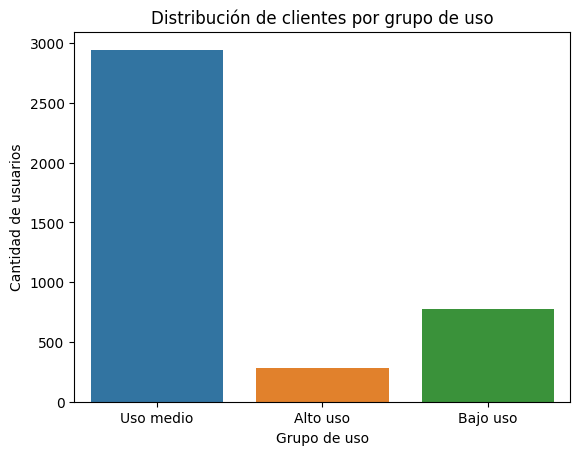

In [66]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso'
)

plt.title('Distribución de clientes por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

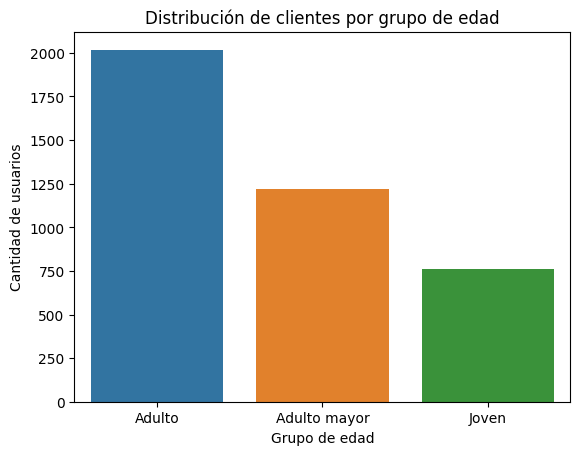

In [67]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x='grupo_edad'
)

plt.title('Distribución de clientes por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

In [68]:
# Relación entre segmento de edad y nivel de uso
pd.crosstab(
    user_profile['grupo_edad'],
    user_profile['grupo_uso'],
    normalize='index'
).mul(100).round(2)

grupo_uso,Alto uso,Bajo uso,Uso medio
grupo_edad,,,
Adulto,7.58,18.09,74.33
Adulto mayor,6.06,21.03,72.91
Joven,6.71,20.66,72.63


In [69]:
# Nivel de uso según plan
pd.crosstab(
    user_profile['grupo_uso'],
    user_profile['plan'],
    normalize='index'
).mul(100).round(2)

plan,Basico,Premium
grupo_uso,,
Alto uso,66.55,33.45
Bajo uso,65.85,34.15
Uso medio,64.46,35.54


In [70]:
# Crear estado del cliente
user_profile['estado_cliente'] = np.where(
    user_profile['churn_date'].notna(),
    'Inactivo',
    'Activo'
)

# Relación entre nivel de uso y estado del cliente
pd.crosstab(
    user_profile['grupo_uso'],
    user_profile['estado_cliente'],
    normalize='index'
).mul(100).round(2)

estado_cliente,Activo,Inactivo
grupo_uso,,
Alto uso,85.97,14.03
Bajo uso,88.58,11.42
Uso medio,88.52,11.48



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
En users, la variable city presentaba 469 valores nulos (11,73 %) y adicionalmente 96 registros con el sentinel ? (2,40 %). En conjunto, aproximadamente 14,13 % de los usuarios no cuenta con una ciudad válida. El sentinel fue transformado en valor nulo para estandarizar la ausencia de información. Para análisis geográficos posteriores se recomienda clasificar estos registros como "No informado" en lugar de asignarles una ciudad artificialmente.

La variable churn_date contenía 3.534 valores nulos (88,35 %). Estos valores no se consideran necesariamente un problema de calidad, ya que pueden representar clientes que no han cancelado el servicio. Por esta razón, se conservaron y pueden utilizarse posteriormente para diferenciar clientes activos e inactivos.

En age se identificó el sentinel -999 en 55 registros, equivalentes aproximadamente al 1,38 % de los usuarios. Debido a que no corresponde a una edad válida, estos registros fueron tratados como datos faltantes e imputados utilizando la mediana. Después de la limpieza, las edades se encuentran entre 18 y 79 años, con una mediana de 48 años.

En reg_date se encontraron 40 registros correspondientes al año 2026 (1 %), a pesar de que el periodo de análisis finaliza en 2024. Estas fechas fueron marcadas como valores nulos (NaT) para evitar introducir información temporal incorrecta sin eliminar completamente a los usuarios afectados.

En usage, date presenta 50 valores faltantes (0,125 %). Además, duration contiene 22.076 nulos (55,19 %) y length 17.896 nulos (44,74 %). El análisis por type mostró que estos últimos son principalmente nulos estructurales: los mensajes no requieren duración y las llamadas no requieren longitud en caracteres, por lo que se conservaron sin imputación.


🔍 **Segmentos por Edad**
Los clientes fueron clasificados en tres grupos: Joven para menores de 30 años, Adulto para clientes entre 30 y 59 años y Adulto mayor para clientes de 60 años en adelante.
La distribución obtenida muestra que el grupo de Adultos es el segmento más numeroso, seguido por los Adultos mayores, mientras que los Jóvenes representan el grupo de menor tamaño. En términos generales, la edad media de la base es de aproximadamente 48 años, con una distribución relativamente amplia entre los 18 y los 79 años.
Esta composición indica que la base de clientes de ConnectaTel tiene una presencia importante de usuarios adultos y adultos mayores. Sin embargo, la edad por sí sola no permite determinar diferencias de consumo; para establecer si alguno de estos grupos utiliza más intensamente los servicios es necesario cruzar grupo_edad con grupo_uso.

📊 **Segmentos por Nivel de Uso**
La segmentación por comportamiento identificó tres grupos: Bajo uso, cuando el usuario registra menos de 5 llamadas y menos de 5 mensajes; Uso medio, cuando registra menos de 10 llamadas y menos de 10 mensajes sin cumplir previamente la condición de bajo uso; y Alto uso para el resto de los usuarios.
El segmento de Uso medio concentra claramente la mayor cantidad de clientes, mientras que el grupo de Alto uso es considerablemente menor. Esto indica que el comportamiento predominante de los usuarios se encuentra en niveles intermedios de llamadas y mensajes.
Desde una perspectiva comercial, el segmento de Uso medio es estratégico por su tamaño, dado que concentra la mayor parte de la base y representa una oportunidad relevante para acciones de retención y migración hacia servicios de mayor valor. Por otra parte, los clientes de Alto uso, aunque son menos numerosos, representan un segmento especialmente interesante por su mayor intensidad de consumo y podrían ser candidatos para ofertas Premium, beneficios adicionales o planes dirigidos a usuarios intensivos.
El segmento de Bajo uso también merece seguimiento. Un bajo nivel de actividad puede corresponder simplemente a las necesidades normales de estos clientes, pero también podría indicar baja utilización del servicio. Antes de asociarlo con riesgo de abandono sería necesario analizar su relación con churn_date.


➡️ Los resultados sugieren que ConnectaTel posee una base predominantemente de uso medio, acompañada por un grupo reducido de usuarios con niveles de consumo considerablemente superiores al promedio. Estos clientes intensivos no deberían tratarse como anomalías que deben eliminarse, sino como posibles segmentos comerciales diferenciados.
Al mismo tiempo, la elevada presencia de clientes adultos y adultos mayores muestra que las estrategias comerciales no deberían diseñarse exclusivamente pensando en usuarios jóvenes. La oferta y comunicación deberían considerar las características de estos grupos predominantes.


💡 **Recomendaciones**
Priorizar estrategias de retención y desarrollo del segmento de Uso medio, debido a que representa la mayor parte de la base. Este grupo constituye una oportunidad para identificar clientes que podrían migrar hacia ofertas de mayor valor.
Analizar separadamente los clientes de Alto uso, especialmente aquellos que superan los límites de IQR. Si su comportamiento es recurrente, podrían justificar una oferta específica orientada a usuarios intensivos.
Investigar el segmento de Bajo uso junto con churn_date. Si se identifica una mayor proporción de cancelaciones en este grupo, podría convertirse en un indicador temprano de riesgo de abandono.
Cruzar edad, nivel de uso, plan y churn antes de diseñar campañas específicas. Esto permitiría determinar, por ejemplo, si existen adultos mayores de alto uso, jóvenes de bajo uso o segmentos con mayor concentración de clientes Premium.
Evaluar la adecuación de los planes Básico y Premium utilizando consumo mensual, no el consumo agregado de todo 2024. Los planes definen beneficios por mes, mientras que actualmente las métricas de user_profile acumulan el uso del periodo analizado; comparar directamente ambas escalas podría producir conclusiones incorrectas sobre sobredimensionamiento o insuficiencia de los planes.
Mantener los outliers válidos en futuros análisis de segmentación, dado que pueden representar comportamientos comerciales relevantes y no errores de calidad

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`